# analysis

this notebook reads prepared real datasets from `data/processed`, calculates hourly lambda for central london, and writes the final data that the html site reads.

In [1]:
import os

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

## load prepared data

`prepare_data.py` creates these files. the notebook does not fetch live data; it only calculates the model from prepared real inputs.

In [2]:
root = os.getcwd()
processed = os.path.join(root, "data", "processed")
out_dir = os.path.join(root, "outputs", "analysis")
web_dir = os.path.join(out_dir, "web")
os.makedirs(web_dir, exist_ok=True)

crs_wgs84, crs_bng = "EPSG:4326", "EPSG:27700"
areas = gpd.read_file(os.path.join(processed, "areas_lsoa.gpkg"))
footfall = pd.read_csv(os.path.join(processed, "station_footfall.csv"))
coords = pd.read_csv(os.path.join(processed, "station_coords.csv"))
rods = pd.read_csv(os.path.join(processed, "rods_profiles.csv"))
bres = pd.read_csv(os.path.join(processed, "bres_section_lsoa.csv"), dtype={"msoa": str})
ashe = pd.read_csv(os.path.join(processed, "ashe_section_pay.csv"))
pois = gpd.read_file(os.path.join(processed, "osm_pois.geojson"))
rough = pd.read_csv(os.path.join(processed, "rough_sleeping_borough.csv"))

msoas = areas["msoa"].tolist()
hours = np.arange(24)
segments = ["workers", "leisure", "shoppers", "tourists", "events", "students"]
len(areas), len(pois), rough.shape

(2130, 18418, (15, 2))

## calculate footfall

tfl station taps give daily volume, rods gives the hourly split, and station coordinates spread the flow to lsoas. the distance scale is derived from the observed median nearest-station distance.

In [3]:
stations = footfall.merge(coords, on="norm").merge(rods, on="norm", how="left")
profile_cols = [f"h{h}" for h in hours]
stations[profile_cols] = stations[profile_cols].fillna(rods[profile_cols].mean())

station_g = gpd.GeoDataFrame(stations, geometry=gpd.points_from_xy(stations["lon"], stations["lat"]), crs=crs_wgs84).to_crs(crs_bng)
area_pts = areas.to_crs(crs_bng).geometry.representative_point()
area_xy = np.c_[area_pts.x, area_pts.y]
station_xy = np.c_[station_g.geometry.x, station_g.geometry.y]
dist = np.linalg.norm(area_xy[:, None, :] - station_xy[None, :, :], axis=2)
weights = np.exp(-dist / np.median(dist.min(axis=1)))

flow = {}
for daytype in ["weekday", "weekend"]:
    station_hourly = stations[daytype].fillna(0).values[:, None] * stations[profile_cols].values
    flow[daytype] = weights @ station_hourly

## calculate real-data segment indices

workers use bres employment weighted by ashe pay. the other segments use real osm poi density by group. these indices are both the spatial anchor and the spend index.

In [4]:
b = bres.set_index("msoa").reindex(msoas).fillna(0)
pay = ashe.set_index("section")["annual_pay"]
pay_sections = [s for s in pay.index if s in b.columns]
jobs = b[pay_sections]
income = (jobs.mul(pay[pay_sections], axis=1).sum(axis=1) / jobs.sum(axis=1).replace(0, np.nan)).fillna(pay.median())
income_index = (income / income[income > 0].median()).clip(0.4, 2.5)

pois_bng = pois.to_crs(crs_bng)
poi_xy = np.c_[pois_bng.geometry.x, pois_bng.geometry.y]
poi_tau = np.median(cKDTree(poi_xy).query(area_xy, k=1)[0])

def poi_density(group):
    sub = pois_bng[pois_bng["poi_group"] == group]
    if sub.empty:
        raise RuntimeError(f"missing prepared osm poi group: {group}")
    xy = np.c_[sub.geometry.x, sub.geometry.y]
    vals = np.exp(-np.linalg.norm(area_xy[:, None, :] - xy[None, :, :], axis=2) / poi_tau).sum(axis=1)
    return pd.Series(vals / np.median(vals[vals > 0]), index=msoas).clip(0.4, 2.5)

index = pd.DataFrame({
    "workers": income_index,
    "leisure": poi_density("leisure"),
    "shoppers": poi_density("shoppers"),
    "tourists": poi_density("tourists"),
    "events": poi_density("events"),
    "students": poi_density("students"),
}, index=msoas)

## calculate segment mix and gross giving

all six segments exist in every lsoa-hour. segment mix and spend come from real-data indices; hourly variation comes from tfl and rods footfall. the only hardcoded behavioural inputs are the base giving probabilities.

In [5]:
p_give = {"workers": 0.010, "leisure": 0.030, "shoppers": 0.012, "tourists": 0.020, "events": 0.030, "students": 0.045}
segment_share = index[segments].div(index[segments].sum(axis=1), axis=0)

gross = {}
for daytype in ["weekday", "weekend"]:
    gross[daytype] = sum(flow[daytype] * segment_share[s].values[:, None] * p_give[s] * index[s].values[:, None] for s in segments)

## calculate competition and final lambda

competition is rough sleepers per unit of gross giving at borough level. final lambda is gross giving multiplied by the data-derived competition factor.

In [6]:
daily_gross = (5 / 7) * gross["weekday"].sum(axis=1) + (2 / 7) * gross["weekend"].sum(axis=1)
borough_gross = areas.assign(gross=daily_gross).groupby("borough")["gross"].sum()
pressure = rough.set_index("borough")["rough_sleepers"] / borough_gross
pressure_norm = (pressure / pressure[pressure > 0].median()).replace([np.inf, -np.inf], np.nan).fillna(1)
competition_factor = 1 / (1 + areas["borough"].map(pressure_norm).fillna(1).values[:, None])
lam = {daytype: gross[daytype] * competition_factor for daytype in ["weekday", "weekend"]}

## export final data

the csv is the complete hourly table. the geojson and data.js are the files read by the html site.

In [7]:
def hourly_table(daytype):
    return pd.DataFrame({
        "msoa": np.repeat(msoas, 24),
        "msoa_name": np.repeat(areas["msoa_name"].values, 24),
        "borough": np.repeat(areas["borough"].values, 24),
        "daytype": daytype,
        "hour": np.tile(hours, len(msoas)),
        "gross": gross[daytype].ravel(),
        "competition_pressure": np.repeat(areas["borough"].map(pressure_norm).fillna(1).values, 24),
        "lambda": lam[daytype].ravel(),
    })

hourly_lambda = pd.concat([hourly_table("weekday"), hourly_table("weekend")], ignore_index=True)
hourly_lambda.to_csv(os.path.join(out_dir, "hourly_lambda.csv"), index=False)

periods = {"morning": [7, 8, 9, 10], "midday": [11, 12, 13, 14, 15], "evening": [17, 18, 19, 20, 21], "late_night": [22, 23, 0, 1, 2]}
surface = areas.copy()
for daytype in ["weekday", "weekend"]:
    for h in hours:
        surface[f"{daytype}_h{h}"] = lam[daytype][:, h]
    for name, hs in periods.items():
        surface[f"{daytype}_{name}"] = lam[daytype][:, hs].mean(axis=1)
surface["daily_lambda"] = (5 / 7) * lam["weekday"].sum(axis=1) + (2 / 7) * lam["weekend"].sum(axis=1)
surface["competition_pressure"] = areas["borough"].map(pressure_norm).fillna(1).values
surface["dominant_crowd"] = index[segments].idxmax(axis=1).values

surface.to_file(os.path.join(out_dir, "lambda_surface.gpkg"), driver="GPKG")
surface_wgs = surface.to_crs(crs_wgs84)
surface_wgs.to_file(os.path.join(web_dir, "lambda_surface.geojson"), driver="GeoJSON")
with open(os.path.join(web_dir, "data.js"), "w") as f:
    f.write("window.LAMBDA_DATA = ")
    f.write(surface_wgs.to_json())
    f.write(";\n")

hourly_lambda.head()

,msoa,msoa_name,borough,daytype,hour,gross,competition_pressure,lambda
0,E01000001,City of London 001A,City of London,weekday,0,75.040426,4.677202,13.217854
1,E01000001,City of London 001A,City of London,weekday,1,8.537984,4.677202,1.503907
2,E01000001,City of London 001A,City of London,weekday,2,0.000000,4.677202,0.000000
3,E01000001,City of London 001A,City of London,weekday,3,0.000000,4.677202,0.000000
4,E01000001,City of London 001A,City of London,weekday,4,0.000000,4.677202,0.000000


## visual checks

these plots check the final hourly pattern and the broad weekday time-period surfaces.

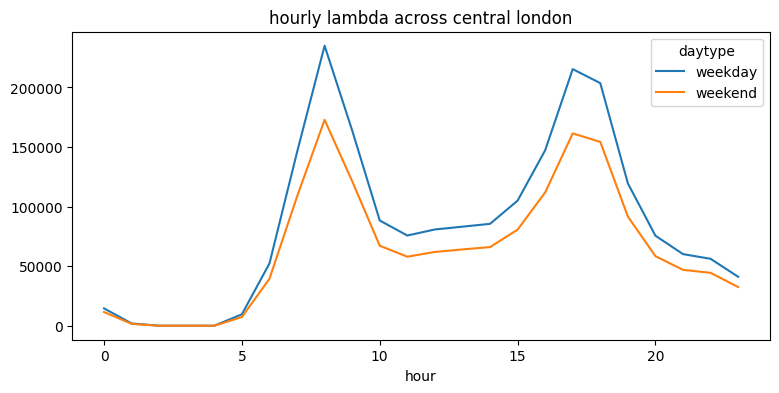

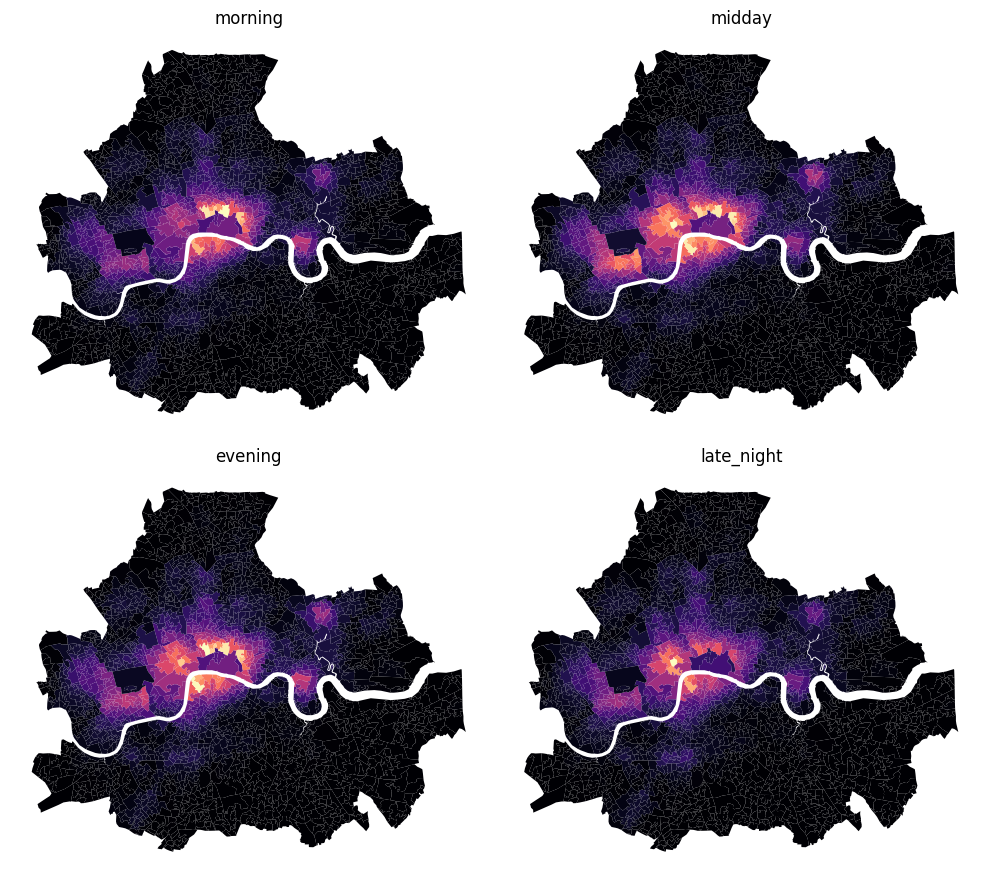

In [8]:
hourly_lambda.groupby(["hour", "daytype"])["lambda"].sum().unstack().plot(figsize=(9, 4), title="hourly lambda across central london")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, (name, hs) in zip(axes.ravel(), periods.items()):
    surface.assign(v=lam["weekday"][:, hs].mean(axis=1)).plot(ax=ax, column="v", cmap="magma", edgecolor="none")
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()